# Pneumonia Detection

##  Name:- Ibarhim Ahmed Saleem   ,id :- 202010799
##  Name:- Farah Naser Al-Rekebat ,id :-  202210500
 


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

sns.set_style("whitegrid")

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.18.0
Num GPUs Available: 0


In [2]:
import os


base_dir = r'C:\Users\Heem\Desktop\chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)


Train dir: C:\Users\Heem\Desktop\chest_xray\train
Val dir: C:\Users\Heem\Desktop\chest_xray\val
Test dir: C:\Users\Heem\Desktop\chest_xray\test


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)



Found 4652 images belonging to 2 classes.
Found 805 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


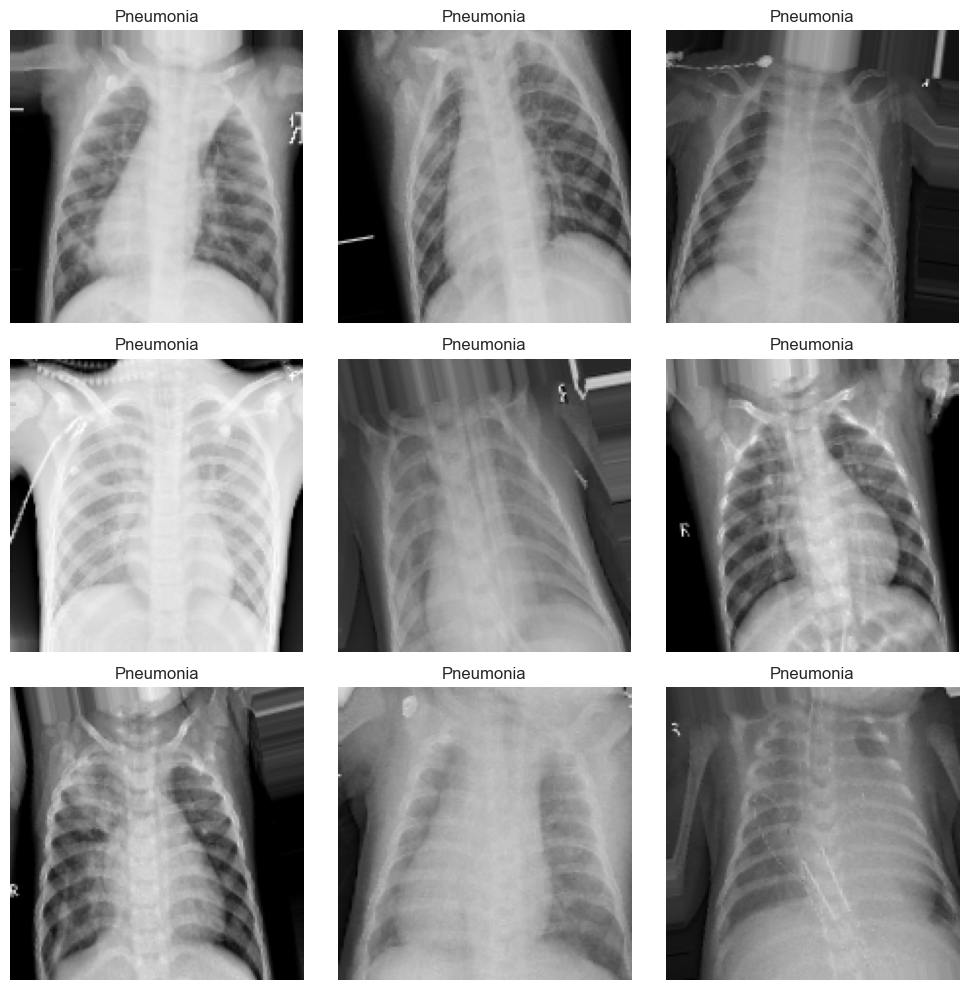

In [4]:
images, labels = next(train_generator)


plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] == 1 else "Normal")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Pneumonia vs Normal
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


D:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
callbacks = [
    EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)


D:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.7754 - loss: 0.5348

146/146 ━━━━━━━━━━━━━━━━━━━━ 71s 480ms/step - accuracy: 0.7756 - loss: 0.5342 - val_accuracy: 0.8311 - val_loss: 0.4301
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 70s 478ms/step - accuracy: 0.8744 - loss: 0.2910 - val_accuracy: 0.8087 - val_loss: 0.5439
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 69s 475ms/step - accuracy: 0.8834 - loss: 0.2691 - val_accuracy: 0.8311 - val_loss: 0.4368
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8936 - loss: 0.2450

146/146 ━━━━━━━━━━━━━━━━━━━━ 70s 477ms/step - accuracy: 0.8936 - loss: 0.2450 - val_accuracy: 0.8969 - val_loss: 0.2569
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 71s 489ms/step - accuracy: 0.9085 - loss: 0.2088 - val_accuracy: 0.9068 - val_loss: 0.2682
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 71s 485ms/step - accuracy: 0.9212 - loss: 0.1972 - val_accuracy: 0.9043 - val_loss: 0.2690
Epoch 7/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 73s 500ms/step - accuracy: 0.9258 - loss: 0.1775 - val_accuracy: 0.8634 - val_loss: 0.3930


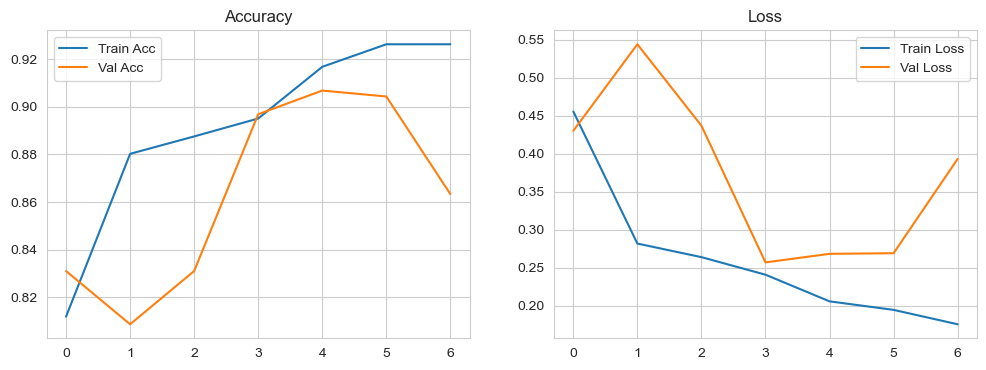

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [8]:
loss, acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.8224 - loss: 0.4260

Test Accuracy: 87.22%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


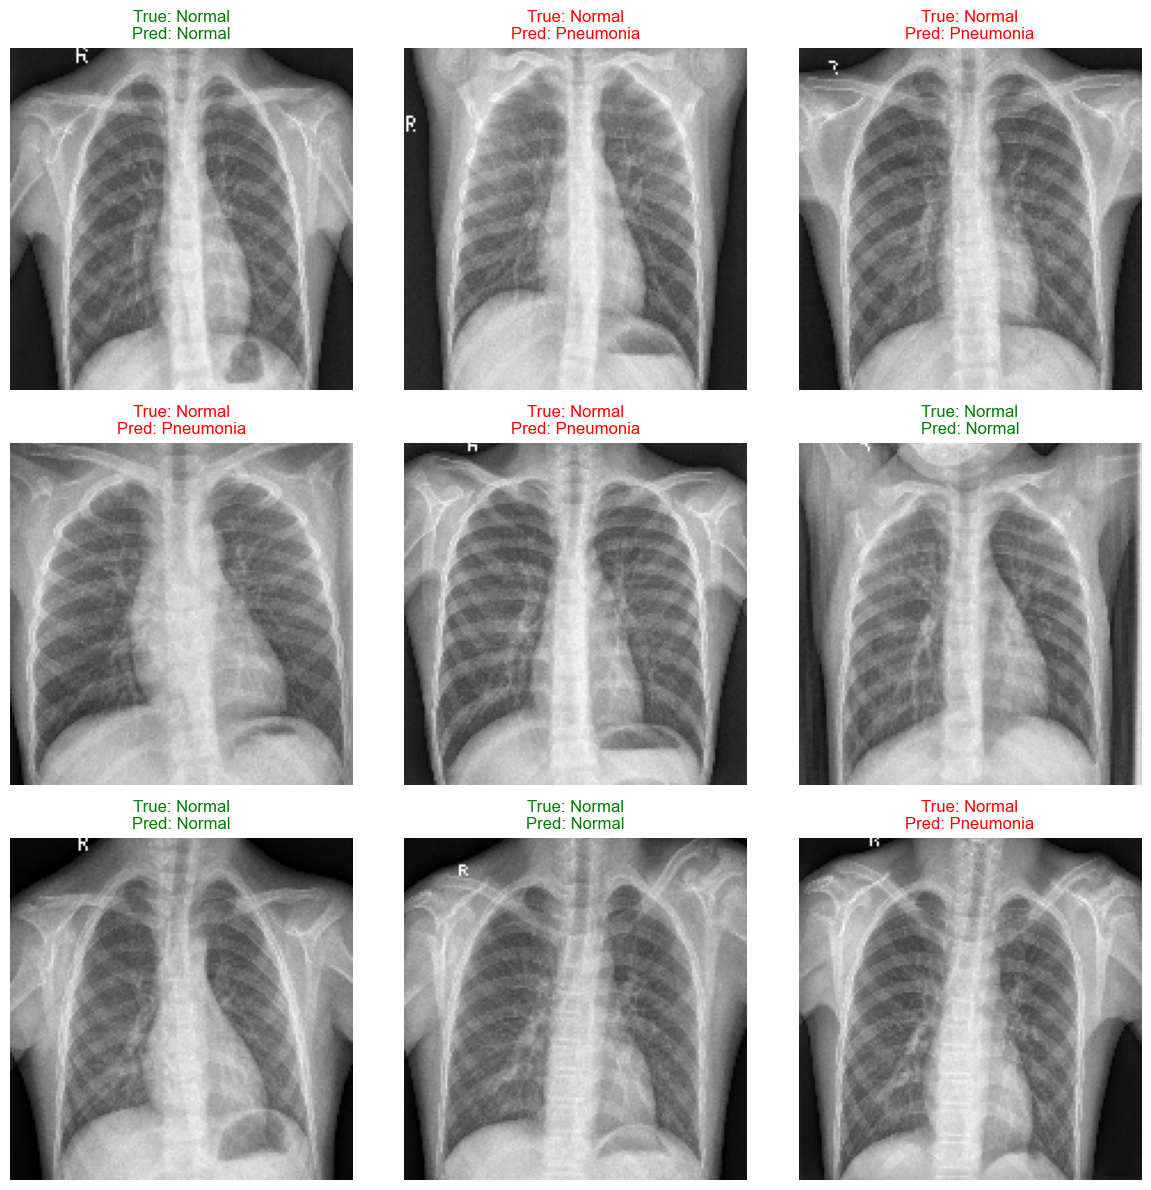

In [9]:
test_images, test_labels = next(test_generator)

predictions = model.predict(test_images)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    true_label = "Pneumonia" if test_labels[i] == 1 else "Normal"
    predicted_label = "Pneumonia" if predicted_classes[i] == 1 else "Normal"
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step
Classification Report:

              precision    recall  f1-score   support

      Normal       0.85      0.79      0.82       147
   Pneumonia       0.88      0.92      0.90       252

    accuracy                           0.87       399
   macro avg       0.87      0.85      0.86       399
weighted avg       0.87      0.87      0.87       399



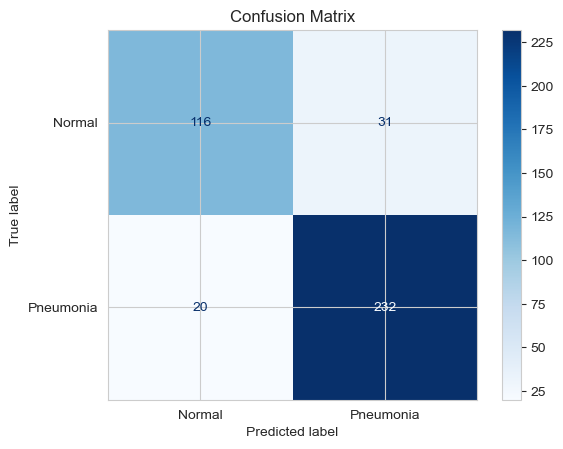

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_generator.reset()


pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()


true_labels = test_generator.classes


report = classification_report(true_labels, pred_labels, target_names=["Normal", "Pneumonia"])
print("Classification Report:\n")
print(report)


cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


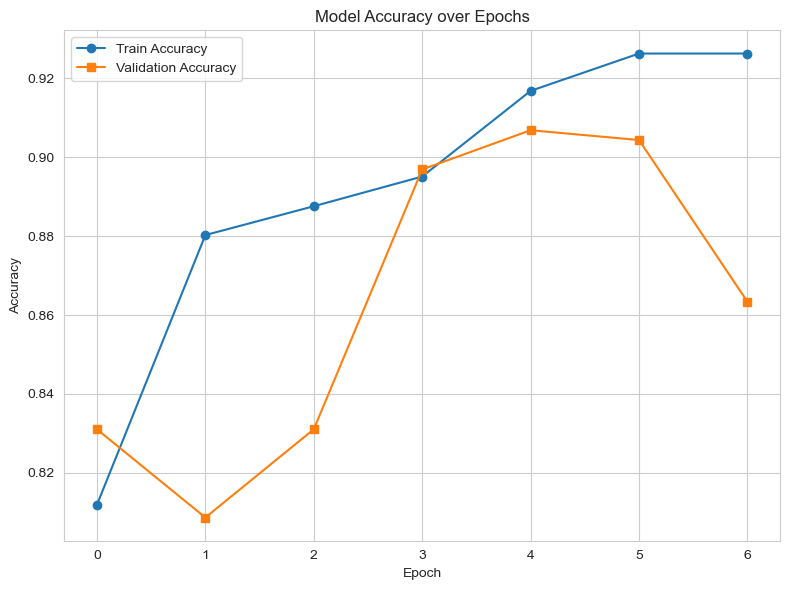

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=base_model.input, outputs=predictions)


model_vgg.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_vgg.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
history_vgg = model_vgg.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ModelCheckpoint('vgg16_best_model.h5', save_best_only=True)
    ]
)


Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.6262 - loss: 0.6467

146/146 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.6270 - loss: 0.6459 - val_accuracy: 0.4248 - val_loss: 0.9209
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.8016 - loss: 0.4472

146/146 ━━━━━━━━━━━━━━━━━━━━ 142s 979ms/step - accuracy: 0.8016 - loss: 0.4472 - val_accuracy: 0.4422 - val_loss: 0.7101
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.8155 - loss: 0.3920

146/146 ━━━━━━━━━━━━━━━━━━━━ 140s 954ms/step - accuracy: 0.8155 - loss: 0.3919 - val_accuracy: 0.5950 - val_loss: 0.6091
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.8417 - loss: 0.3402

146/146 ━━━━━━━━━━━━━━━━━━━━ 142s 973ms/step - accuracy: 0.8417 - loss: 0.3401 - val_accuracy: 0.7106 - val_loss: 0.5351
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.8702 - loss: 0.3038

146/146 ━━━━━━━━━━━━━━━━━━━━ 138s 945ms/step - accuracy: 0.8702 - loss: 0.3038 - val_accuracy: 0.7727 - val_loss: 0.4822
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.8740 - loss: 0.2768

146/146 ━━━━━━━━━━━━━━━━━━━━ 141s 965ms/step - accuracy: 0.8741 - loss: 0.2768 - val_accuracy: 0.8273 - val_loss: 0.4243
Epoch 7/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.8991 - loss: 0.2555

146/146 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8991 - loss: 0.2556 - val_accuracy: 0.8410 - val_loss: 0.4018
Epoch 8/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8988 - loss: 0.2483 - val_accuracy: 0.8112 - val_loss: 0.4249
Epoch 9/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.9093 - loss: 0.2334

146/146 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9093 - loss: 0.2334 - val_accuracy: 0.8360 - val_loss: 0.3924
Epoch 10/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9038 - loss: 0.2398 - val_accuracy: 0.8149 - val_loss: 0.4176


In [14]:
loss, acc = model_vgg.evaluate(test_generator)
print(f"\n🔍 VGG16 Test Accuracy: {acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 759ms/step - accuracy: 0.7811 - loss: 0.4689

🔍 VGG16 Test Accuracy: 85.46%


In [15]:
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()
true_labels = test_generator.classes


print(classification_report(true_labels, pred_labels, target_names=["Normal", "Pneumonia"]))


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step
              precision    recall  f1-score   support

      Normal       0.85      0.79      0.82       147
   Pneumonia       0.88      0.92      0.90       252

    accuracy                           0.87       399
   macro avg       0.87      0.85      0.86       399
weighted avg       0.87      0.87      0.87       399



In [32]:
import os
import random
import shutil

def move_images(source_dir, target_dir, percentage=0.1):
   
    os.makedirs(target_dir, exist_ok=True)

   
    files = os.listdir(source_dir)
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

  
    num_to_move = int(len(files) * percentage)
    files_to_move = random.sample(files, num_to_move)

    print(f"Moving {num_to_move} images from {source_dir} to {target_dir}...")

    for file in files_to_move:
        src_path = os.path.join(source_dir, file)
        dst_path = os.path.join(target_dir, file)
        shutil.move(src_path, dst_path)


base_path = r"C:\Users\Heem\Desktop\chest_xray"
categories = ["NORMAL", "PNEUMONIA"]

for category in categories:
    train_path = os.path.join(base_path, "train", category)
    val_path = os.path.join(base_path, "val", category)
    move_images(train_path, val_path, percentage=0.1)


Moving 97 images from C:\Users\Heem\Desktop\chest_xray\train\NORMAL to C:\Users\Heem\Desktop\chest_xray\val\NORMAL...
Moving 367 images from C:\Users\Heem\Desktop\chest_xray\train\PNEUMONIA to C:\Users\Heem\Desktop\chest_xray\val\PNEUMONIA...


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    r"C:\Users\Heem\Desktop\chest_xray\train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\Heem\Desktop\chest_xray\val",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\Heem\Desktop\chest_xray\test",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # مهم لاختبار الأداء بدقة
)


Found 4188 images belonging to 2 classes.
Found 1269 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))


for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=base_model.input, outputs=predictions)

model_vgg.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])


In [38]:
history = model_vgg.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(patience=2, restore_best_weights=True)
    ]
)


D:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.7114 - loss: 0.5906 - val_accuracy: 0.5587 - val_loss: 0.7205
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7968 - loss: 0.4652 - val_accuracy: 0.5690 - val_loss: 0.5962
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8030 - loss: 0.4130 - val_accuracy: 0.6612 - val_loss: 0.5237
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8292 - loss: 0.3637 - val_accuracy: 0.8251 - val_loss: 0.4412
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8598 - loss: 0.3272 - val_accuracy: 0.8519 - val_loss: 0.4060


In [39]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

model_vgg.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_finetune = model_vgg.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(patience=2, restore_best_weights=True),
        ModelCheckpoint('finetuned_vgg16_best.h5', save_best_only=True)
    ]
)


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9011 - loss: 0.2351

131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9012 - loss: 0.2349 - val_accuracy: 0.9165 - val_loss: 0.2211
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.9340 - loss: 0.1639

131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9340 - loss: 0.1639 - val_accuracy: 0.9243 - val_loss: 0.1988
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9551 - loss: 0.1286 - val_accuracy: 0.9236 - val_loss: 0.2001
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9523 - loss: 0.1264

131/131 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9524 - loss: 0.1264 - val_accuracy: 0.9330 - val_loss: 0.1819
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9557 - loss: 0.1142 - val_accuracy: 0.9314 - val_loss: 0.1883


In [40]:
loss, acc = model_vgg.evaluate(test_generator)
print(f"\n🔍 Final Fine-Tuned Accuracy: {acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 796ms/step - accuracy: 0.9370 - loss: 0.2088

🔍 Final Fine-Tuned Accuracy: 94.99%


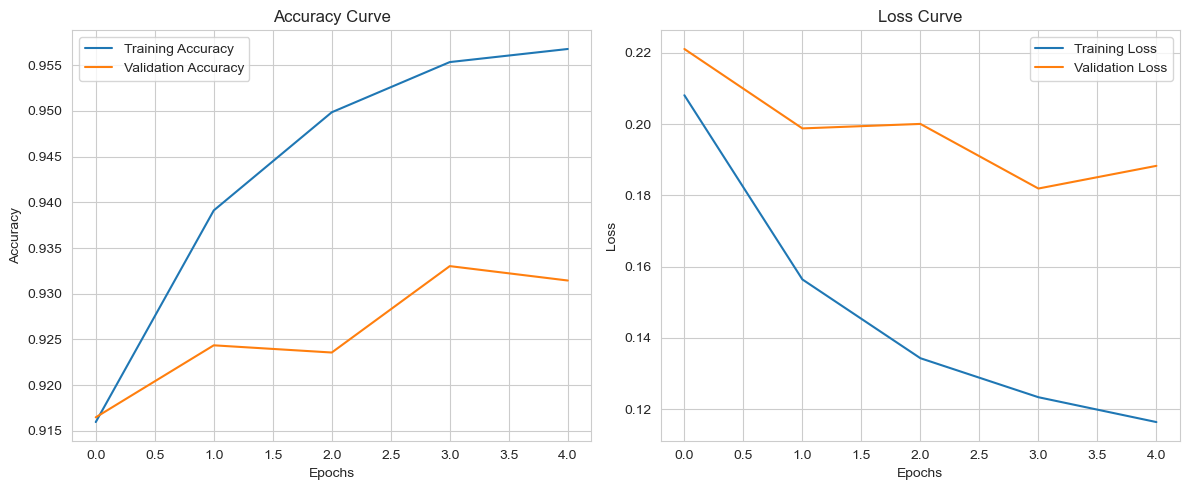

In [42]:
import matplotlib.pyplot as plt


history_data = history_finetune  


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_data.history['accuracy'], label='Training Accuracy')
plt.plot(history_data.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_data.history['loss'], label='Training Loss')
plt.plot(history_data.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


C:\Users\Heem\AppData\Local\Temp\ipykernel_5500\3511592284.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_labels[int(preds[i])]


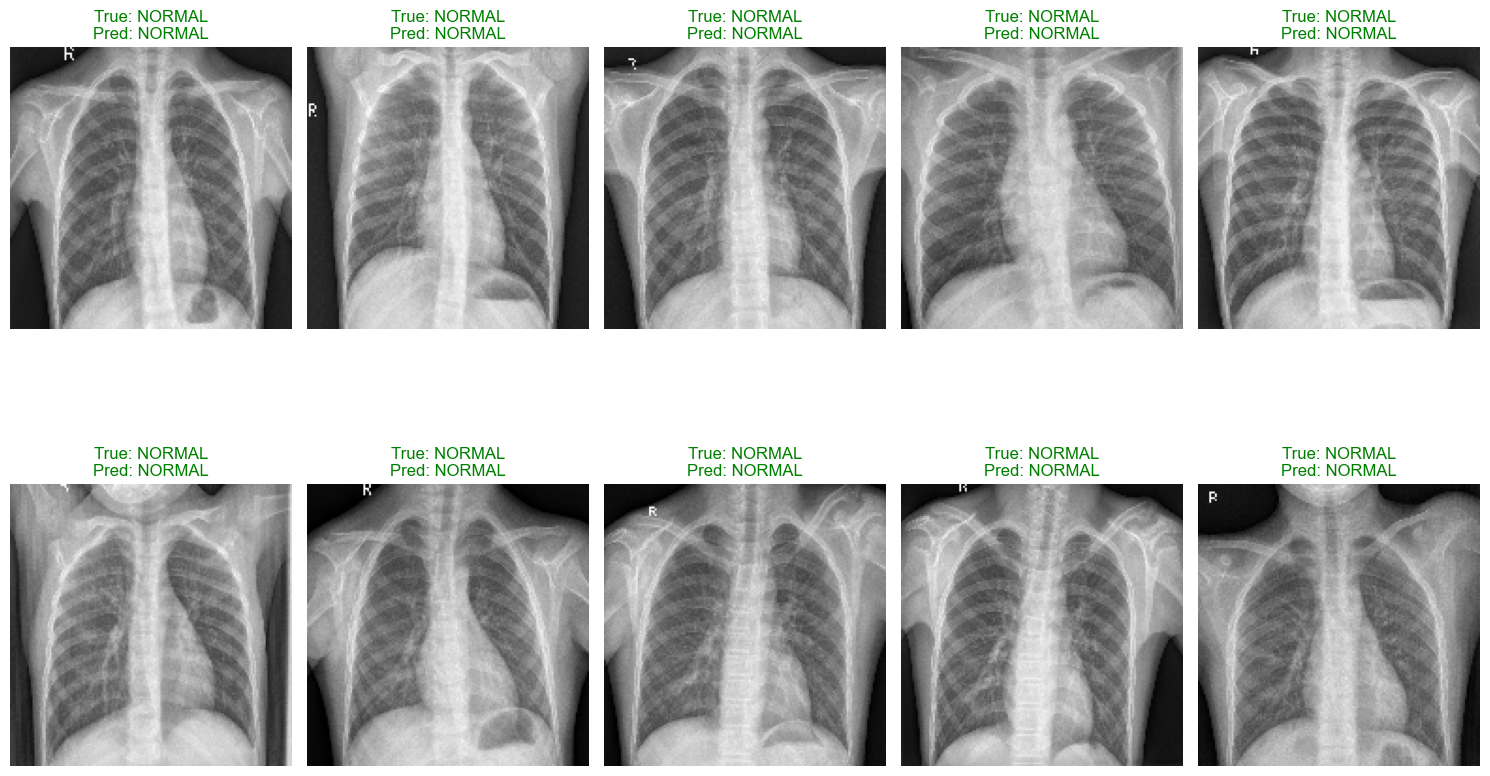

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

class_labels = list(test_generator.class_indices.keys())

x_test, y_test = next(test_generator)
preds = model_vgg.predict(x_test)
preds = (preds > 0.5).astype(int)

plt.figure(figsize=(15, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    true_label = class_labels[int(y_test[i])]
    pred_label = class_labels[int(preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = test_generator.classes
y_pred_probs = model_vgg.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


print("🔍 Confusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)
print(cm)


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 731ms/step
📊 Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.96      0.90      0.93       147
   PNEUMONIA       0.95      0.98      0.96       252

    accuracy                           0.95       399
   macro avg       0.95      0.94      0.95       399
weighted avg       0.95      0.95      0.95       399

🔍 Confusion Matrix:

[[133  14]
 [  6 246]]
